# About this notebook
> This is the notebook we used to select our CAS13 guide RNA sequences. <br>
> Important: this is not the simplest notebook to understand, maybe have a look at the others first <br>
> This notebook is left unchanged, therefore new functions simplifying the intermediate selection process (see mini, dev or mCherry) are not used here. <br>
> Special about this notebook: similar to dev this is the full depth of features including analysis of combinations of queries against a weighted transcriptome
> Special2: Here we used ViennaRNA binding site accessability scores to preselect which binding sites to evaluate


# How to check all possible target binding sites against off-target binding sites in whole transcriptome
We have a target mRNA that we want to bind with RNA binding proteins. To design these pumby proteins we need to select binding sites on our target mRNA which are very unique, i.e. ideally dont occure elsewhere the transcriptome.  Or more general: We have a target sequence and we want to find a subsequence of specified length which is as specific to this target as possible i.e. has the least interactions with dataset of reference sequences. 


In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from time import time
import warnings
import pathlib
import scipy.stats as stats
from joblib import Parallel, delayed
from tqdm import tqdm
import math
from main_search import sc_jit, query_sc_summary, sc_summarize, query_sc, df_PCA, df_map, df_table, _col_weights
from numba import njit
from IPython.display import display
from sequence_reader import read_fasta, _ensembl_fasta_to_dict

## Import data


#### General Fasta importer - mCherry Sequencing results

In [2]:
mCherry = read_fasta("sequence_data/iGEM_mCherry_V2.fasta").iloc[0]
mCherry.SEQUENCE = mCherry.SEQUENCE.upper()
mCherry

SEQ_NAME                               iGEM_mCherry_BBa_E2060
SEQUENCE    ATGGCAACTAGCGGCATGGTTAGTAAAGGAGAAGAAAATAACATGG...
Name: 0, dtype: object

#### read ensembl FASTA and decode description
 - for FASTA data from https://ftp.ensembl.org/pub/

In [3]:
files = ["sequence_data/Saccharomyces_cerevisiae.R64-1-1.ncrna.fa", "sequence_data/Saccharomyces_cerevisiae.R64-1-1.cdna.all.fa", "sequence_data/Saccharomyces_cerevisiae.R64-1-1.cds.all.fa"]  # -> different transcripts in each DataFrame -> data has to be concatenated
_df = pd.concat([read_fasta(file) for file in files], ignore_index=True)
df_seq = pd.concat([_df.SEQ_NAME.apply(_ensembl_fasta_to_dict).apply(pd.Series), _df.SEQUENCE], axis = 1).drop_duplicates(ignore_index = True) # split description into respective columns i.e. decode ensebl fasta description
df_seq

,SEQ_NAME,chromosome,gene,gene_biotype,transcript_biotype,SEQUENCE
0,ETS2-2_rRNA,R64-1-1:XII:460712:460922:-1,ETS2-2,rRNA,NaN,TTTTTATTTCTTTCTAAGTGGGTACTGGCAGGAGCCGGGGCCTAGT...
1,ITS2-2_rRNA,R64-1-1:XII:464319:464550:-1,ITS2-2,rRNA,NaN,CCTTCTCAAACATTCTGTTTGGTAGTGAGTGATACTCTTTGGAGTT...
2,RDN18-1_rRNA,R64-1-1:XII:455933:457732:-1,RDN18-1,rRNA,NaN,TATCTGGTTGATCCTGCCAGTAGTCATATGCTTGTCTCAAAGATTA...
3,Q0020_rRNA,R64-1-1:Mito:6546:8194:1,Q0020,rRNA,rRNA,GTAAAAAATTTATAAGAATATGATGTTGGTTCAGATTAAGCGCTAA...
4,RDN5-5_rRNA,R64-1-1:XII:485697:485815:1,RDN5-5,rRNA,NaN,GGTTGCGGCCATATCTACCAGAAAGCACCGTTTCCCGTCCGATCAA...
...,...,...,...,...,...,...
7035,YIL170W,R64-1-1:IX:19847:21220:1,YIL170W,pseudogene,pseudogene,ATGGGTTTGATTGTCTCAATATTCAACATTGGCTGCGCCATAGGCG...
7036,YMR242C_mRNA,R64-1-1:XIII:753225:753742:-1,YMR242C,protein_coding,protein_coding,GCTCACTTTAAAGAATACCAAGTTATTGGCCGTCGTTTGCCAACTG...
7037,YOR312C_mRNA,R64-1-1:XV:900250:900767:-1,YOR312C,protein_coding,protein_coding,GCTCATTTCAAAGAATACCAAGTCATTGGTCGTCGTTTACCAACTG...
7038,YJL041W_mRNA,R64-1-1:X:365903:368373:1,YJL041W,protein_coding,protein_coding,AACTTCAATACACCTCAACAAAACAAAACGCCCTTTTCGTTCGGGA...


#### read TPM.tsv files - quantitative transcriptome
data from https://www.ebi.ac.uk/gxa/experiments?species=%22saccharomyces+cerevisiae%22&experimentType=%22Baseline%22

In [4]:
files = ["sequence_data/E-MTAB-8621-query-results.tpms.tsv", "sequence_data/E-MTAB-8626-query-results.tpms.tsv"] # same genes under different conditions -> data has to be merged
_df = pd.read_csv(files[0], sep = '\t', skiprows = 4)
for file in files[1:]:
    _df = pd.merge(_df, pd.read_csv(file, sep = '\t', skiprows = 4) , how = "outer", on = ["Gene ID", "Gene Name"])

df_tpm = _df.drop(columns = _df.filter(like="minute").columns) # combine timeseries data by taking the max of the found expression
df_tpm["tpm_max"] = _df.filter(like="minute").max(axis = 1, skipna = True, numeric_only = True)
df_tpm

,Gene ID,Gene Name,tpm_max
0,ETS1-1,ETS1-1,72.0
1,ETS1-2,ETS1-2,3.0
2,ETS2-1,ETS2-1,8.0
3,HRA1,HRA1,3.0
4,ICR1,ICR1,5.0
...,...,...,...
6782,tY(GUA)F2,SUP6,3.0
6783,tY(GUA)J1,SUP7,9.0
6784,tY(GUA)J2,SUP4,3.0
6785,tY(GUA)M1,SUP5,6.0


### merge sequence and tpm data

In [5]:
transcriptome = pd.merge(df_seq, df_tpm, left_on="gene", right_on="Gene ID", how = "outer") 
transcriptome = transcriptome[~transcriptome.SEQUENCE.isna()]                               # delete entries witho9ut a sequence
transcriptome.loc[transcriptome.tpm_max.isna(), "tpm_max"] = transcriptome.tpm_max.max()                   # if transcript count (TPM) is unknown, expect the worst
transcriptome["WEIGHT"] = transcriptome.tpm_max
mCherry["WEIGHT"] = transcriptome.tpm_max.mean()
transcriptome

,SEQ_NAME,chromosome,gene,gene_biotype,transcript_biotype,SEQUENCE,Gene ID,Gene Name,tpm_max,WEIGHT
0,ETS1-1_rRNA,R64-1-1:XII:457733:458432:-1,ETS1-1,rRNA,NaN,ATGCGAAAGCAGTTGAAGACAAGTTCGAAAAGAGTTTGGAAACGAA...,ETS1-1,ETS1-1,72.0,72.0
1,ETS1-2_rRNA,R64-1-1:XII:466870:467569:-1,ETS1-2,rRNA,NaN,ATGCGAAAGCAGTTGAAGACAAGTTCGAAAAGAGTTTGGAAACGAA...,ETS1-2,ETS1-2,3.0,3.0
2,ETS2-1_rRNA,R64-1-1:XII:451575:451785:-1,ETS2-1,rRNA,NaN,TTTTTATTTCTTTCTAAGTGGGTACTGGCAGGAGCCGGGGCCTAGT...,ETS2-1,ETS2-1,8.0,8.0
3,ETS2-2_rRNA,R64-1-1:XII:460712:460922:-1,ETS2-2,rRNA,NaN,TTTTTATTTCTTTCTAAGTGGGTACTGGCAGGAGCCGGGGCCTAGT...,NaN,NaN,22546.0,22546.0
4,HRA1_ncRNA,R64-1-1:I:99305:99868:1,HRA1,ncRNA,NaN,GGGCCCTTTCTTCCGTTTGAACGTAAAGGCATTTTTGAGACCATTA...,HRA1,HRA1,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...
7083,tY(GUA)J2_tRNA,R64-1-1:X:542956:543044:-1,tY(GUA)J2,tRNA,tRNA,CTCTCGGTAGCCAAGTTGGTTTAAGGCGCAAGACTGTAAATCTTGA...,tY(GUA)J2,SUP4,3.0,3.0
7084,tY(GUA)M1_tRNA,R64-1-1:XIII:168795:168883:1,tY(GUA)M1,tRNA,tRNA,CTCTCGGTAGCCAAGTTGGTTTAAGGCGCAAGACTGTAAATCTTGA...,tY(GUA)M1,SUP5,6.0,6.0
7085,tY(GUA)M2_tRNA,R64-1-1:XIII:837928:838016:1,tY(GUA)M2,tRNA,tRNA,CTCTCGGTAGCCAAGTTGGTTTAAGGCGCAAGACTGTAAATCTTGA...,NaN,NaN,22546.0,22546.0
7086,tY(GUA)O_tRNA,R64-1-1:XV:288192:288280:1,tY(GUA)O,tRNA,tRNA,CTCTCGGTAGCCAAGTTGGTTTAAGGCGCAAGACTGTAAATCTTGA...,tY(GUA)O,SUP3,3.0,3.0


### Load mcherry secondary structure scores

In [6]:
def iseq(seq):
    "invert a sequence: bases and direction"
    return seq.lower().replace("a", "T").replace("t", "A").replace("c", "G").replace("g", "C")[::-1]

In [7]:
mCherry_secstructure = pd.read_csv("sequence_data/mcherry-rna-secstructure-CasRxguides.csv").rename(columns={'GuideSeq': 'SEQUENCE', 'GuideName': 'SEQ_NAME', 'MatchPos':'POSITION' })
mCherry_secstructure["WEIGHT"] = 1
mCherry_secstructure.SEQUENCE = mCherry_secstructure.SEQUENCE.apply(iseq)
mCherry_secstructure.loc[:,["GuideScores", "Rank", "standardizedGuideScores"]] *= -1
mCherry_secstructure

,SEQ_NAME,SEQUENCE,POSITION,GuideScores,Rank,standardizedGuideScores,quartiles,WEIGHT
0,crRNA336:336-358,TGGCGTGGTAACAGTGACTCAGG,358,-1.358254,-0.998600,-0.913186,4,1
1,crRNA515:536-558,ATGGTGGACATTATGACGCTGAG,558,-1.323466,-0.997200,-0.893866,4,1
2,crRNA580:601-623,GGTGCTTACAATGTAAATATAAA,623,-1.315502,-0.995900,-0.889443,4,1
3,crRNA578:599-621,CAGGTGCTTACAATGTAAATATA,621,-1.313184,-0.994500,-0.888156,4,1
4,crRNA516:537-559,TGGTGGACATTATGACGCTGAGG,559,-1.300853,-0.993100,-0.881308,4,1
...,...,...,...,...,...,...,...,...
719,crRNA167:167-189,TAAAAGTTACTAAGGGTGGCCCA,189,0.129648,-0.005525,-0.086875,1,1
720,crRNA382:382-404,TTTATCTACAAAGTCAAATTAAG,404,0.129760,-0.004144,-0.086812,1,1
721,crRNA166:166-188,CTAAAAGTTACTAAGGGTGGCCC,188,0.132534,-0.002762,-0.085272,1,1
722,crRNA381:381-403,ATTTATCTACAAAGTCAAATTAA,403,0.136348,-0.001381,-0.083154,1,1


<br>
<br>
<br>

# Search for off-target binding-sites on single transcript 
= global sequence comparison of query with a reference sequence
- as we are searching for binding sites in the transcriptome, we'd ideally find as few as possible to avoid unwanted side-effects.
- As the binding sites are usually shorter then the persistence length of the polymers, a global sequence alignment search should suffice (we dont need BLAST)

,SEQ_NAME,SEQUENCE,POSITION,GuideScores,Rank,standardizedGuideScores,quartiles,WEIGHT,chromosome,gene,gene_biotype,transcript_biotype,Gene ID,Gene Name,tpm_max
562,crRNA495:516-538,ACAAAGATTGAAATTGAAAGATG,538.0,-0.053415,-0.2224,-0.188539,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2877,YHR068W_mRNA,ATGTCCGATATCAACGAAAAACTCCCAGAGTTACTACAAGACGCTG...,NaN,NaN,NaN,NaN,NaN,286.0,R64-1-1:VIII:232133:233296:1,YHR068W,protein_coding,protein_coding,YHR068W,DYS1,286.0


{'mismatch_eq_0': np.int64(0), 'mismatch_eq_1': np.int64(0), 'mismatch_eq_2': np.int64(0), 'boltzmann factor': np.float64(1.240824180753361e-08)}


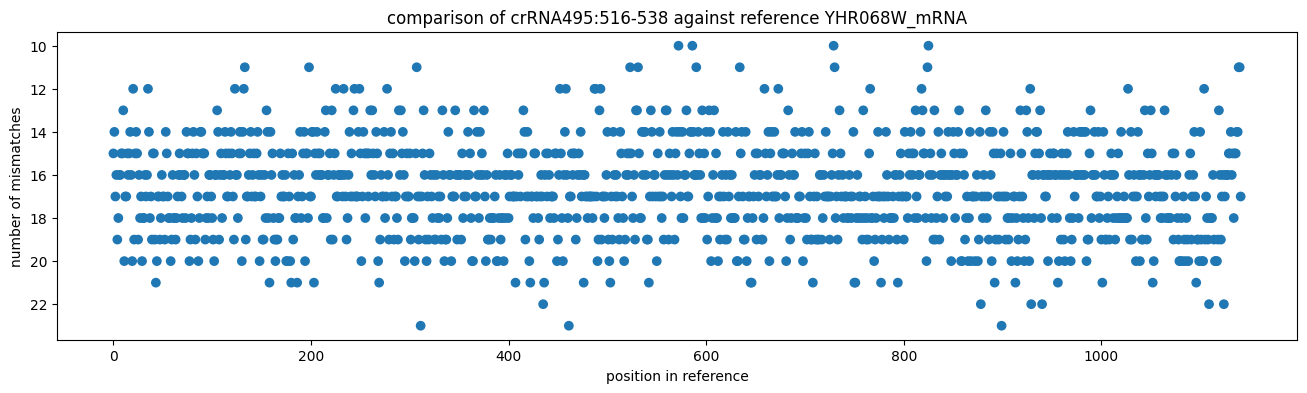

In [8]:
# check random potential binding site = target subsequence against random transcript

query = mCherry_secstructure.sample().iloc[0]
ref = transcriptome.sample().iloc[0]
display(pd.DataFrame([query, ref]) )


mm = len(query.SEQUENCE)-sc_jit(query.SEQUENCE.encode(), ref.SEQUENCE.encode()) # mm = number of mismatches at each possible binding position; encoding strings into bytes is faster for some reason; sc_jit returns the number of matches thats why mm = len - sc

sc_results = {}  # summarize the possible binding sites of the query sequence against one reference sequence i.e. a transcript from the transcriptome
sc_results["mismatch_eq_0"] = (mm==0).sum()                  # number of idential matches
sc_results["mismatch_eq_1"] = (mm==1).sum()                  # number of matches with 1 mismatch
sc_results["mismatch_eq_2"] = (mm==2).sum()                  # number of matches with 2 mistmatches
sc_results["boltzmann factor"] = np.sum(np.exp(-2.0*mm))     # a very basic prediction of how likely the query sequence would bind to the reference. The wildtype pumilios have ~ 18 hydrogen bonds for 8nt i.e. 2.25 hydgrogen bonds = 2.25kT per bp, however the pumby appears to only have ~2 H-bonds per bp, and the binding statistics suggest closer to 1kT -> lets go with 1.5 for now, in the future a more accurate model might be implemented. Currently the boltzmann_factor for a perfect match is 1, if therefore this predicted boltzmann_factor is smaller than 1 than it is more likly to bind to the specific RNA, while if it is larger than one it is more likely to bind to the background transcriptom 

if True:       
    plt.figure(figsize=(16, 4))
    plt.scatter(np.arange(mm.size), mm, c = np.array(["tab:red", "tab:green", "tab:orange", "tab:blue"])[np.clip(mm, 0, 3)])
    plt.gca().invert_yaxis()
    plt.ylabel("number of mismatches")
    plt.xlabel(f"position in reference")
    plt.title(f"comparison of {query.SEQ_NAME} against reference {ref.SEQ_NAME}")

print(sc_results)

,SEQ_NAME,SEQUENCE,POSITION,GuideScores,Rank,standardizedGuideScores,quartiles,WEIGHT
203,crRNA510:531-553,GAAAGATGGTGGACATTATGACG,553.0,-0.630267,-0.7182,-0.508896,3.0,1.000000
0,iGEM_mCherry_BBa_E2060,ATGGCAACTAGCGGCATGGTTAGTAAAGGAGAAGAAAATAACATGG...,NaN,NaN,NaN,NaN,NaN,1226.278267


{'mismatch_eq_0': np.int64(1), 'mismatch_eq_1': np.int64(0), 'mismatch_eq_2': np.int64(0), 'boltzmann factor': np.float64(1.0000000363810688)}


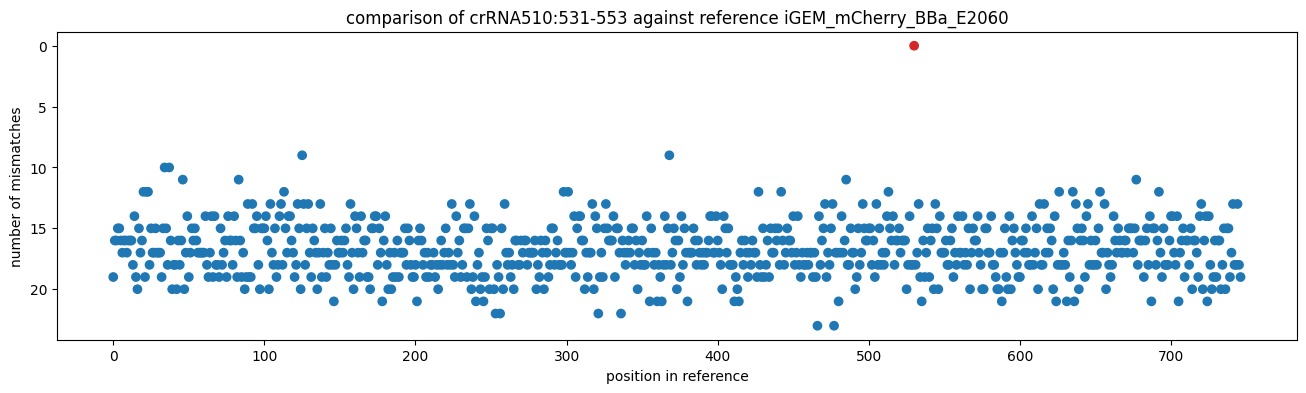

In [9]:
# check random potential binding site = target subsequence against the full target

query = mCherry_secstructure.sample().iloc[0]
ref = mCherry
display(pd.DataFrame([query, ref]) )


mm = len(query.SEQUENCE)-sc_jit(query.SEQUENCE.encode(), ref.SEQUENCE.encode()) # mm = number of mismatches at each possible binding position; encoding strings into bytes is faster for some reason; sc_jit returns the number of matches thats why mm = len - sc

sc_results = {}  # summarize the possible binding sites of the query sequence against one reference sequence i.e. a transcript from the transcriptome
sc_results["mismatch_eq_0"] = (mm==0).sum()                  # number of idential matches
sc_results["mismatch_eq_1"] = (mm==1).sum()                  # number of matches with 1 mismatch
sc_results["mismatch_eq_2"] = (mm==2).sum()                  # number of matches with 2 mistmatches
sc_results["boltzmann factor"] = np.sum(np.exp(-2.0*mm))     # a very basic prediction of how likely the query sequence would bind to the reference. The wildtype pumilios have ~ 18 hydrogen bonds for 8nt i.e. 2.25 hydgrogen bonds = 2.25kT per bp, however the pumby appears to only have ~2 H-bonds per bp, and the binding statistics suggest closer to 1kT -> lets go with 1.5 for now, in the future a more accurate model might be implemented. Currently the boltzmann_factor for a perfect match is 1, if therefore this predicted boltzmann_factor is smaller than 1 than it is more likly to bind to the specific RNA, while if it is larger than one it is more likely to bind to the background transcriptom 

if True:       
    plt.figure(figsize=(16, 4))
    plt.scatter(np.arange(mm.size), mm, c = np.array(["tab:red", "tab:green", "tab:orange", "tab:blue"])[np.clip(mm, 0, 3)])
    plt.gca().invert_yaxis()
    plt.ylabel("number of mismatches")
    plt.xlabel(f"position in reference")
    plt.title(f"comparison of {query.SEQ_NAME} against reference {ref.SEQ_NAME}")

print(sc_results)


## Test good candidate binding sequences (in parallel)
 - compare a selection of target-sequence substrings of specific length to reference dataset


In [10]:
# generate random input sequences for this test
reference_dataset = transcriptome        # The references to check against, i.e. the transcriptome in this example
target            = mCherry              # The sequence from which we want ot find the best/unique binding site
query_len = 12                           # length of the binding sites (usually 8-12 for pumby)

# only check possible binding sites with good secondary structure accessibility
query_dataset = mCherry_secstructure[mCherry_secstructure.quartiles == 4]


# compare possible binding sites against whole transcriptome
query_sc_summary(query_dataset.sample().iloc[0], reference_dataset, target) # testrun to make sure everything is ok, because for some stupid reason parallelised executions do not return warnings anymore
results = pd.DataFrame(list(tqdm(total=len(query_dataset), ncols = 100, 
        iterable=Parallel(return_as="generator", n_jobs=-1)(  # using joblib instead of multiprocessing becasue of windows compatibility
            delayed(query_sc_summary)(query, reference_dataset, target) for _, query in query_dataset.iterrows())
        )))

100%|█████████████████████████████████████████████████████████████| 138/138 [00:32<00:00,  4.26it/s]


In [11]:

def _col_weights(col):
    col_name = col.name
    if "W." in col_name or "Score" in col_name: m = 2
    else: m = 1
    if "identical" in col_name or "boltzman" in col_name  or "GuideScores" in col_name or "standardizedGuideScores" in col_name:    return m*1
    elif "1nt" in col_name:                                  return m*1/2
    elif "2nt" in col_name:                                  return m*1/4
    else:                                                    return m*1/8
    

DF = results.copy()
position_cols = [col for col in DF.columns if col.startswith("POSITION")]
DFnum = DF.select_dtypes(np.number).drop(position_cols, axis = 1)
rel_ranks = (DFnum.rank() + DFnum.rank(method = "dense"))/ (2*len(DF) +1) # relative total number, i.e. within 0...1
weighted_ranks = 2**(rel_ranks.apply(stats.norm.ppf)) * DFnum.apply(_col_weights) 

DF["rank max"] = weighted_ranks.max(axis = 1) 
DF["rank sum"] = weighted_ranks.mean(axis = 1)  
DF["rank score"] = DF["rank max"] +  DF["rank sum"]
DF["selected"] = 0


# selection

 - select low nt mismatches first
 - select for locally for each 1/n segments of target seperatly to ensure good binding site distribution
 - filter out VIR duplicates at the end.

/tmp/ipykernel_18056/895136399.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected = DF.index.isin(df.groupby('bin')['rank score'].nsmallest(nsmallest).reset_index(level=0, drop=True).index)


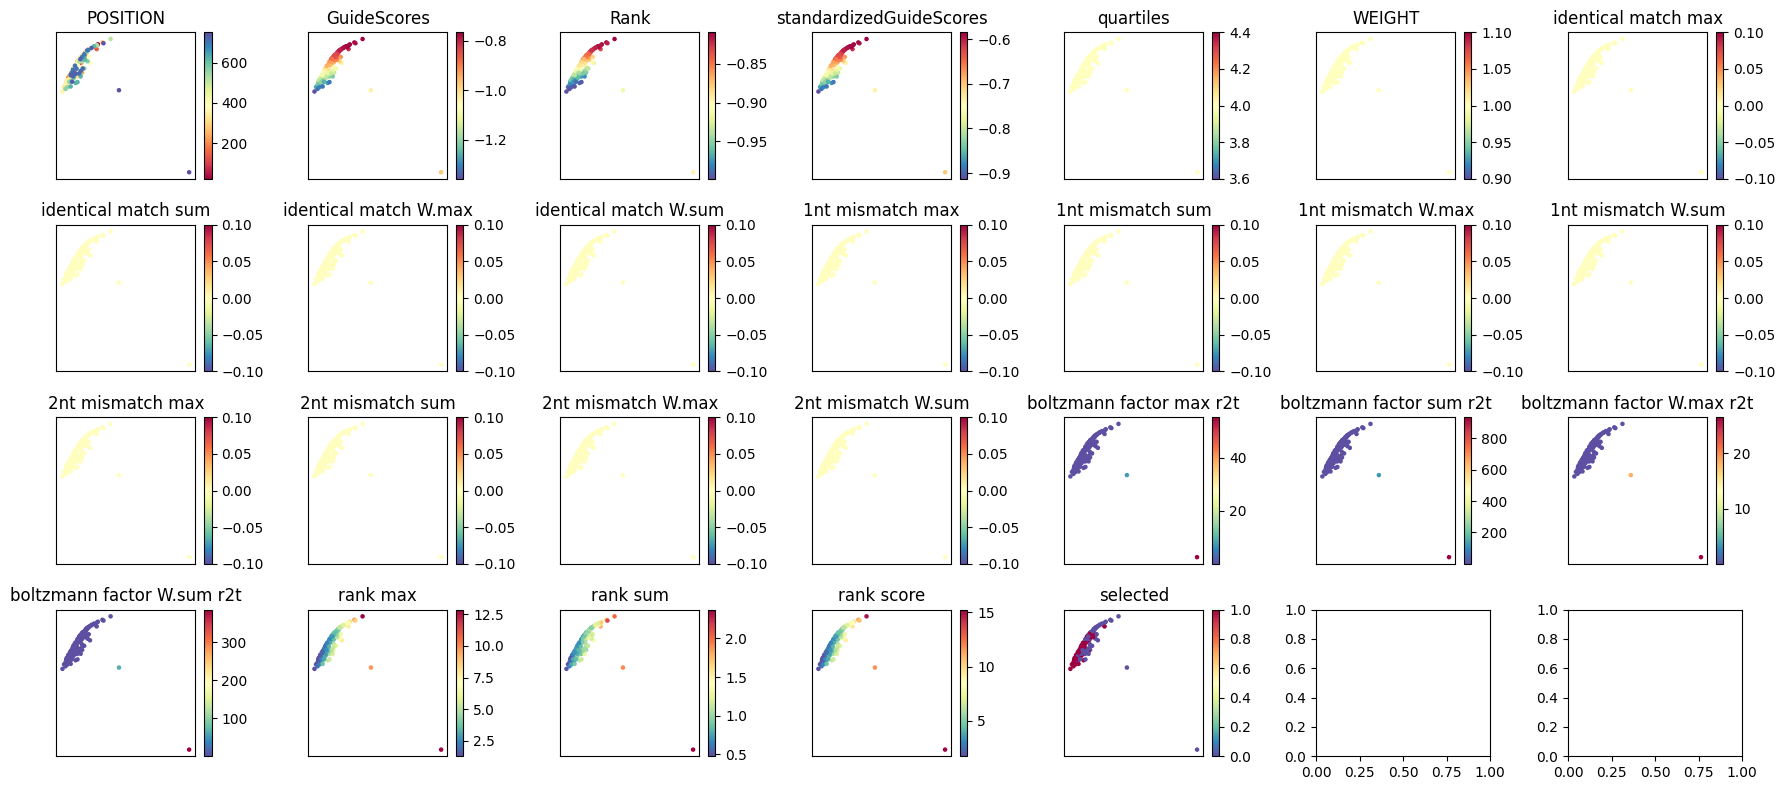

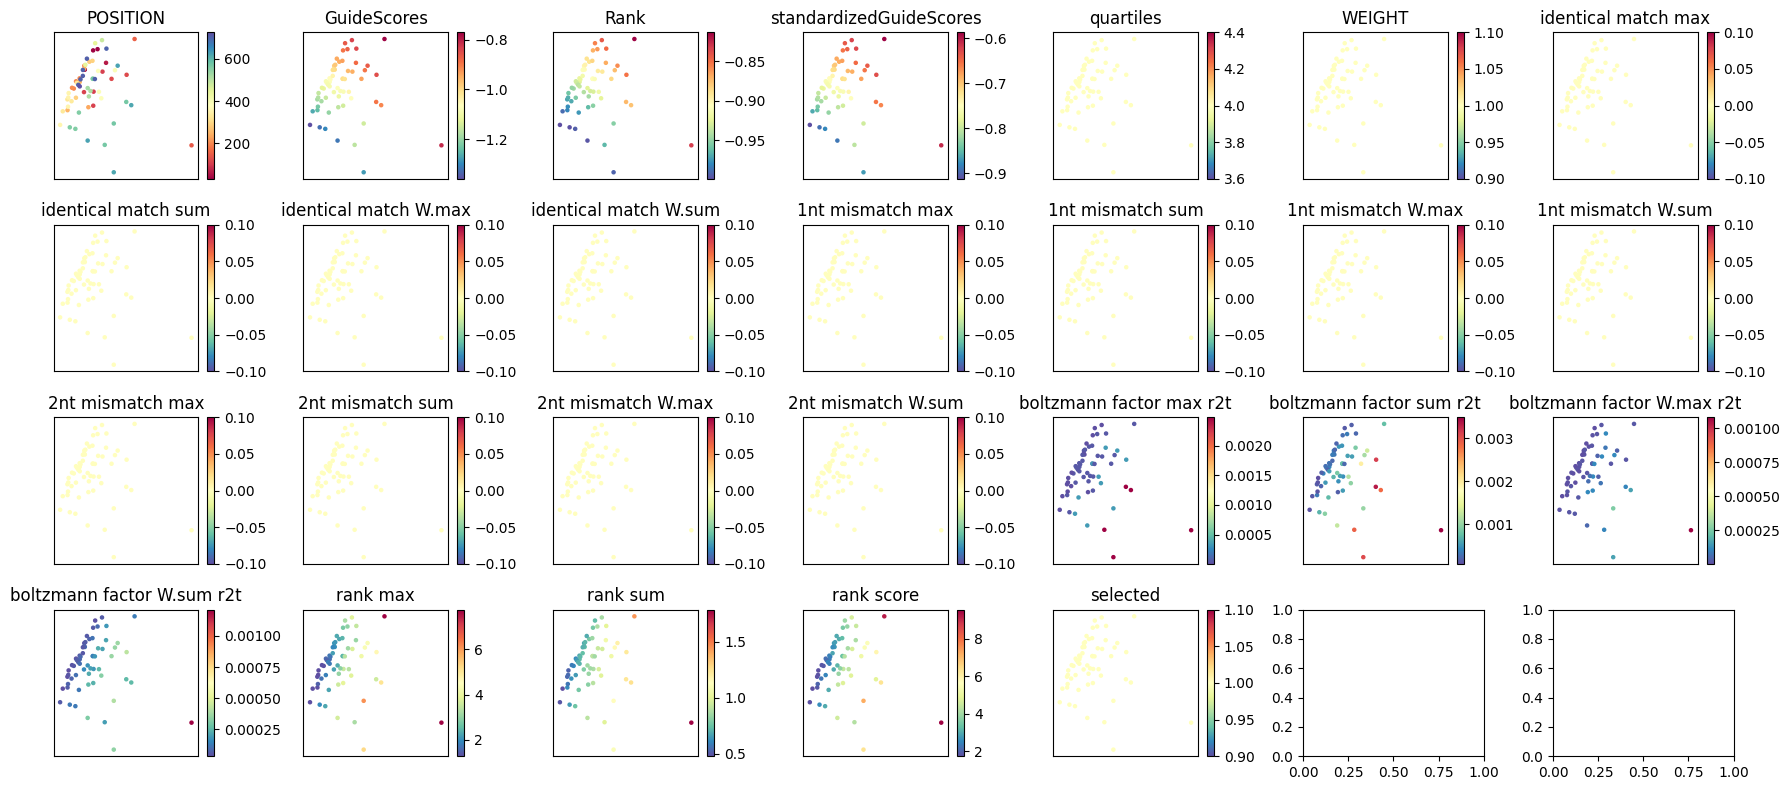

/mnt/Data/GIT/iGEM2025-TRAPS-Software-and-Modelling/main_search.py:373: RuntimeWarning: invalid value encountered in log10
  mag = -int(np.floor(np.log10(x))-digits+1)


In [12]:
### Selection stage 1 ### - select evenly distributed a fixed number of samples

nbins = 16
nsmallest = 4
df = DF.copy()

df['bin'] = pd.cut(df.POSITION, bins=nbins)
selected = DF.index.isin(df.groupby('bin')['rank score'].nsmallest(nsmallest).reset_index(level=0, drop=True).index)
DF.loc[selected, "selected"] = 1
DF.loc[~selected, "selected"] = 0
DF = DF.sort_values(by=["POSITION"])

df_PCA(DF)
df_PCA(DF[DF.selected == 1])
df_table(DF)


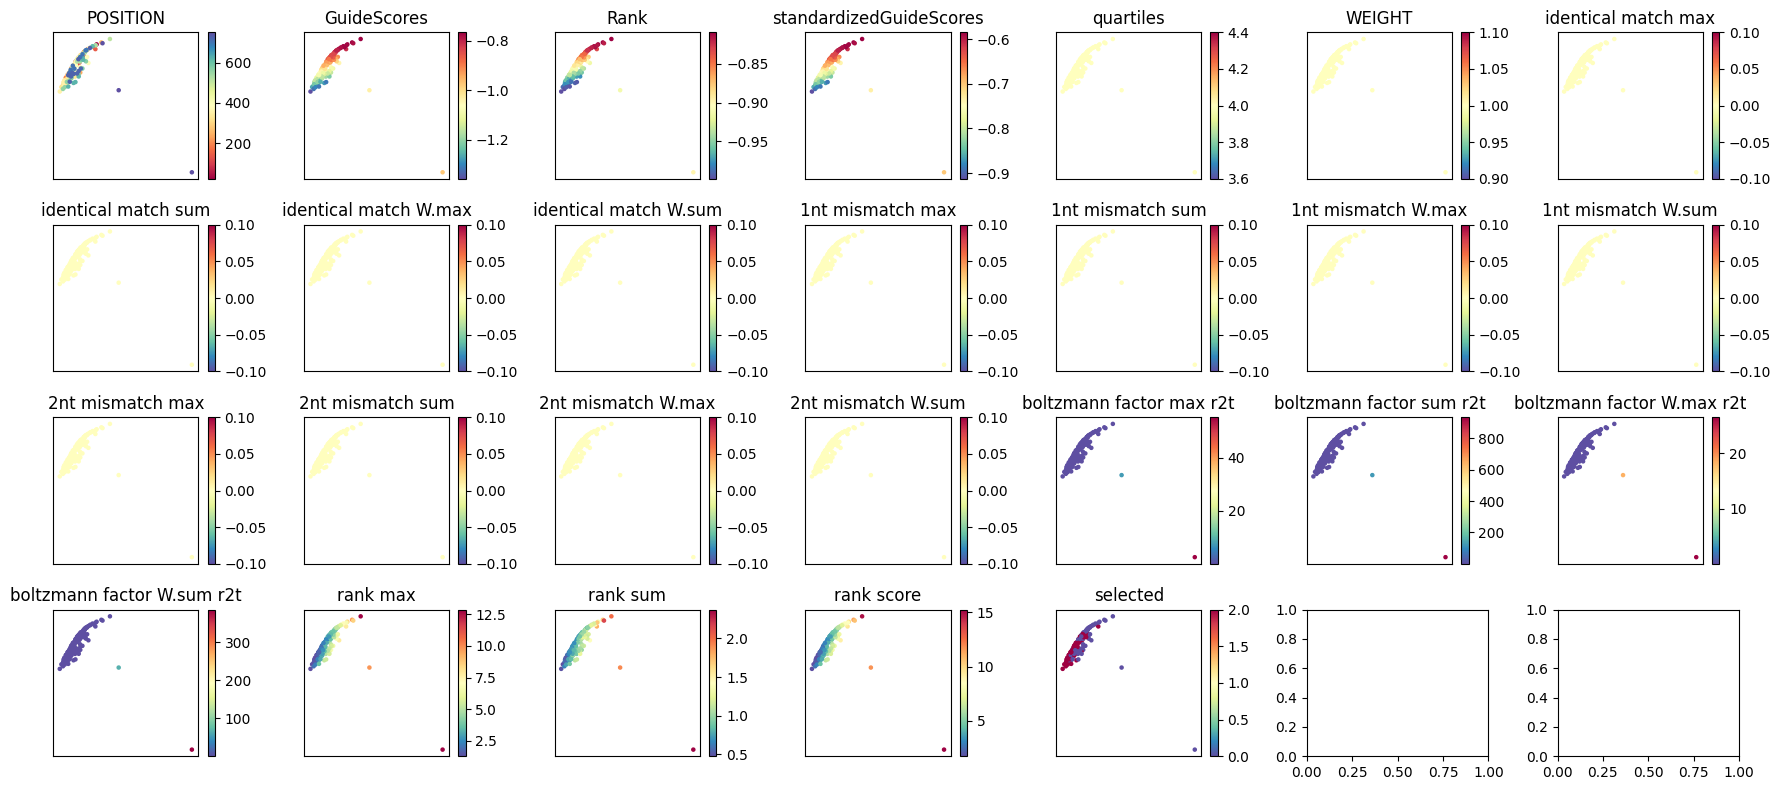

/mnt/Data/GIT/iGEM2025-TRAPS-Software-and-Modelling/main_search.py:373: RuntimeWarning: invalid value encountered in log10
  mag = -int(np.floor(np.log10(x))-digits+1)


In [13]:
min_select = 32
o = 0
df_num = DF[DF["selected"]>0].copy().select_dtypes('number').drop(["selected"]+position_cols, axis = 1)
while True:
    o += 0.001
    sel = (df_num < o*df_num.median() - (1-o)*df_num.min()).sum(axis = 1 )
    I_sel = list(sel[(sel == max(sel.max(), 1))].index)
    if len(I_sel) > min_select:
        break
DF.loc[DF.selected == 2, "selected"] = 1
DF.loc[I_sel,"selected"] = 2

df_PCA(DF)
df_table(DF) 

# Combinatorial optimization

In [14]:
### search for offtarget binding sites of the remaining selection

query_dataset = DF[DF.selected == DF.selected.max()]
sc_refs = pd.concat([pd.DataFrame([target]), reference_dataset], axis = 0)  # include target in sequence comparison

def query_sc_wrapper(query:pd.Series, reference_dataset:pd.DataFrame)->pd.DataFrame:
    return [query, query_sc(query, reference_dataset)]

qnsc_results = list(tqdm(total=len(query_dataset), ncols = 100,
        iterable = Parallel(return_as="generator", n_jobs=-1)(
            delayed(query_sc_wrapper)(query, sc_refs) for _, query in query_dataset.iterrows() )))


100%|███████████████████████████████████████████████████████████████| 62/62 [00:37<00:00,  1.67it/s]


In [15]:
qnsc_results[0][0]

SEQ_NAME                                                         crRNA010:10-32
SEQUENCE                                                AGCGGCATGGTTAGTAAAGGAGA
POSITION                                                                     32
GuideScores                                                           -0.893042
Rank                                                                    -0.8702
standardizedGuideScores                                               -0.654829
quartiles                                                                     4
WEIGHT                                                                        1
identical match max                                                         0.0
identical match sum                                                         0.0
identical match VIR                                                          []
identical match W.max                                                       0.0
identical match W.sum                   

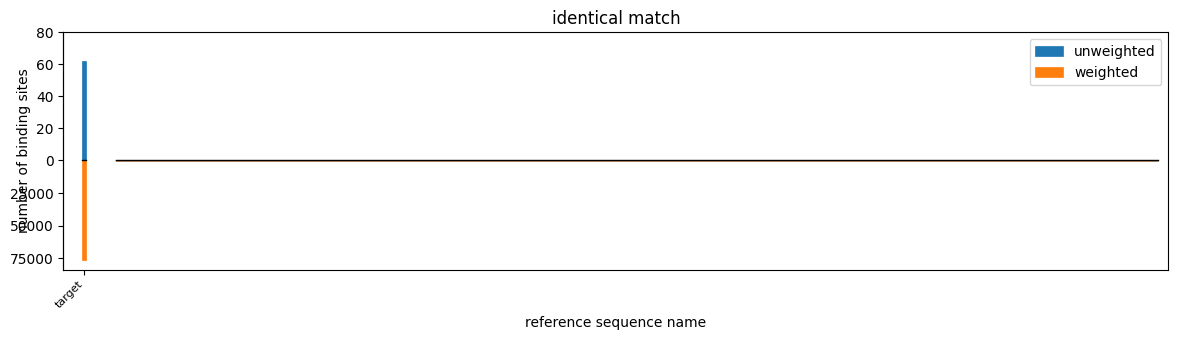

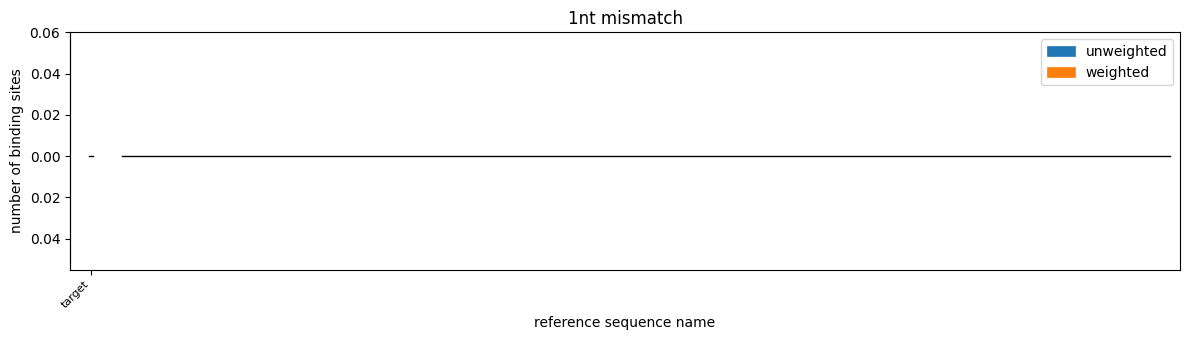

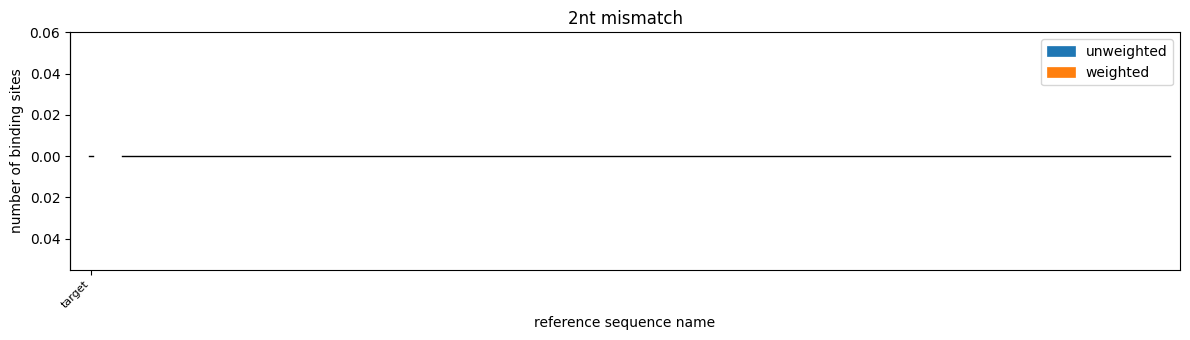

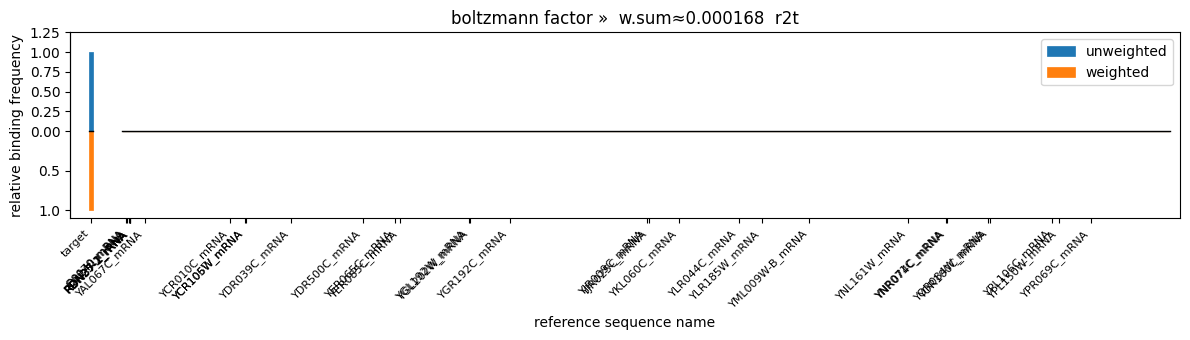

POSITION 0                                                                   32
POSITION 1                                                                   33
POSITION 2                                                                   34
POSITION 3                                                                   63
POSITION 4                                                                  103
                                                    ...                        
boltzmann factor sum r2t                                               0.000753
boltzmann factor VIR          [YPL150W_mRNA, YNL161W_mRNA, YJR025C_mRNA, YLR...
boltzmann factor W.max r2t                                             0.000018
boltzmann factor W.sum r2t                                             0.000168
boltzmann factor W.VIR        [YJR025C_mRNA, YER085C_mRNA, YNL161W_mRNA, YGL...
Length: 87, dtype: object

In [16]:
positions = {}
metrics = ["identical match", "1nt mismatch", "2nt mismatch", "boltzmann factor"]
weight = 0
for i, (query, scr) in enumerate(qnsc_results):
    positions |= {f"POSITION {i}": query.POSITION}
    weight += query.WEIGHT
    if i == 0:
        references_scr = scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)  # results from the comparison with the reference dataset (sequences to avoid)
        target_scr     = scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0]  # results from the comparison with the target sequence
    else:
        references_scr[metrics] += scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)[metrics]  # results from the comparison with the reference dataset (sequences to avoid)
        target_scr[metrics]     += scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0][metrics]  # results from the comparison with the target sequence

sc_summarize(pd.Series(positions|{"WEIGHT": weight}), references_scr,  target_scr, plot = True, VIR_max = 32) # summary of all candidates together

### evaluate all permutations of *n* queries

In [17]:
from itertools import combinations
metrics = ["identical match", "1nt mismatch", "2nt mismatch", "boltzmann factor"]

def combo_summarize(combo_sc_results, use_weights: bool = True, VIR_max: int = 32, r2t: bool = True):
    positions = {}
    sequences = {}
    seq_names = {}
    weight = {"WEIGHT": 0}
    for i, (query, scr) in enumerate(combo_sc_results):
        positions |= {f"POSITION {i}": query.POSITION}
        sequences |= {f"SEQUENCE {i}": query.SEQUENCE}
        seq_names |= {f"SEQ_NAME {i}": query.SEQ_NAME}
        weight["WEIGHT"] += query.WEIGHT

        if i == 0:
            references_scr = scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)  # results from the comparison with the reference dataset (sequences to avoid)
            target_scr     = scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0]  # results from the comparison with the target sequence
        else:
            references_scr[metrics] += scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)[metrics]  # results from the comparison with the reference dataset (sequences to avoid)
            target_scr[metrics]     += scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0][metrics]  # results from the comparison with the target sequence
    return sc_summarize(pd.Series(positions | sequences | seq_names | weight), references_scr,  target_scr, use_weights=use_weights, VIR_max=VIR_max, r2t=r2t, plot = False)


##### round 1 - all permutations of 2 pumbys

In [18]:
### search for offtarget binding sites of permutations from remaining selection

n_query = 2
min_distance = 64

qnscr_dict = {qnsc_results[i][0].POSITION: qnsc_results[i] for i in range(len(qnsc_results))}                                                              
query_combos = [(p1, p2) for p1, p2 in list(combinations(qnscr_dict.keys(), n_query)) if abs(p1-p2) > min_distance]  # compute all possible combinations of 2 queries i.e. binding sites, but make sure there is a bit of space inbetween

combo_sc_data = [[qnscr_dict[query_position] for query_position in query_combo] for query_combo in query_combos]  # prepare sequence comparison results from earlier in the groups of two
qc_results = pd.DataFrame([combo_summarize(csd) for csd in tqdm(combo_sc_data, total = len(combo_sc_data), ncols = 100)]) # evaluate the combined sequence comparison results for each group of queries

100%|███████████████████████████████████████████████████████████| 1586/1586 [02:57<00:00,  8.95it/s]


257


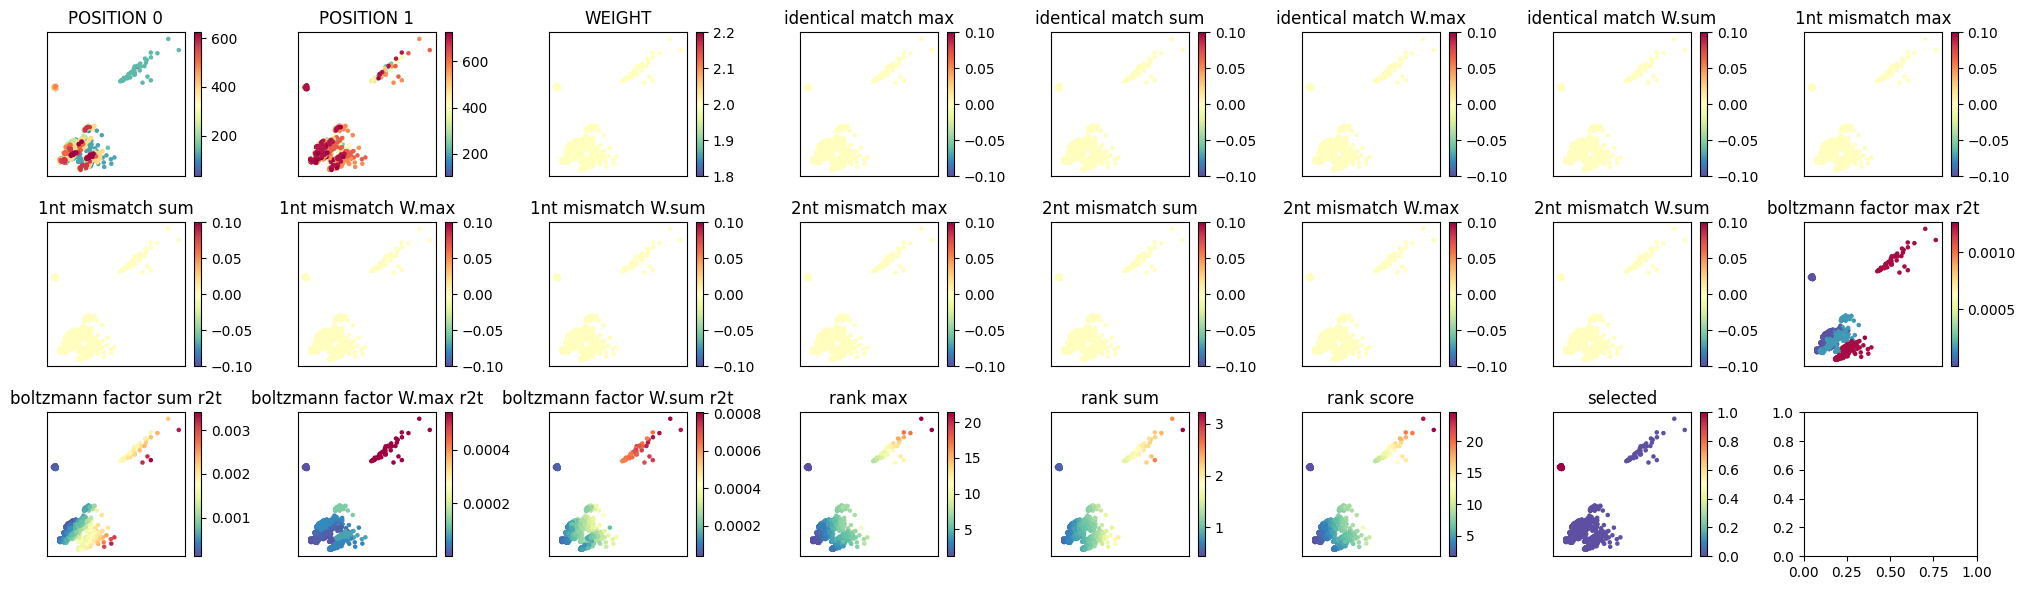

In [19]:
DF = qc_results
min_select = 256


position_cols = [col for col in DF.columns if col.startswith("POSITION")]
DFnum = DF.select_dtypes(np.number).drop(position_cols, axis = 1)
rel_ranks = (DFnum.rank() + DFnum.rank(method = "dense"))/ (2*len(DF) +1) # relative total number, i.e. within 0...1
weighted_ranks = 2**(rel_ranks.apply(stats.norm.ppf)) * DFnum.apply(_col_weights)  


DF["rank max"] = weighted_ranks.max(axis = 1) 
DF["rank sum"] = weighted_ranks.mean(axis = 1)  
DF["rank score"] = DF["rank max"] +  DF["rank sum"]
DF["selected"] = 0


df = DF.copy()

DF_num = DF.copy().select_dtypes('number').drop(["selected"]+position_cols, axis = 1)
df_num = DF_num.copy()
for o in np.arange(0, 1, 0.001):
    _quant = (df_num < (1-o)*DF_num.median() - (o)*DF_num.min()).sum(axis = 1 )
    if len(df_num) - (_quant == _quant.min()).sum() > min_select:
        df_num = df_num.drop(_quant[_quant == _quant.min()].index)

DF.loc[DF.selected == 1, "selected"] = 0
DF.loc[df_num.index,"selected"] = 1

print(sum(DF.selected == 1))
df_PCA(DF)
df_table(DF, ignore_columns_like = ["VIR", "SEQ_NAME", "SEQUENCE"])


### round 2 finding good tetramers

4968/28339 fullfilled min-distance of 64


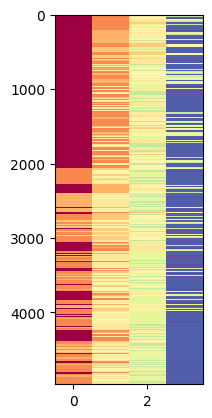

In [20]:
selected = DF[DF.selected == 1]
query_combos = []
n = 0
for set1, set2 in combinations(selected.apply(lambda row: set((row['POSITION 0'], row['POSITION 1'])), axis=1).values, 2):
    union = np.sort(list(set1 | set2))
    if len(union) == 4:
        n += 1
        if ((union[1:]-union[:-1]) > min_distance).all():
            query_combos.append(tuple(set1 | set2))

query_combos = list(set(query_combos))
query_combos.sort()
query_combos = [np.sort(qc).tolist() for qc in query_combos]
plt.imshow(query_combos, cmap = "Spectral", interpolation="nearest", aspect = 10/len(query_combos));
print(f"{len(query_combos)}/{n} fullfilled min-distance of {min_distance}")

In [21]:
combo_sc_data = [[qnscr_dict[query_position] for query_position in query_combo] for query_combo in query_combos]  # prepare sequence comparison results from earlier in the groups of two
qc_results = pd.DataFrame([combo_summarize(csd) for csd in tqdm(combo_sc_data, total = len(combo_sc_data), ncols = 100)]) # evaluate the combined sequence comparison results for each group of queries

100%|███████████████████████████████████████████████████████████| 4968/4968 [02:39<00:00, 31.16it/s]


In [22]:
DF = qc_results

position_cols = [col for col in DF.columns if col.startswith("POSITION")]
DFnum = DF.select_dtypes(np.number).drop(position_cols, axis = 1)
rel_ranks = (DFnum.rank() + DFnum.rank(method = "dense"))/ (2*len(DF) +1) # relative total number, i.e. within 0...1
weighted_ranks = 2**(rel_ranks.apply(stats.norm.ppf)) * DFnum.apply(_col_weights)  

DF["rank max"] = weighted_ranks.max(axis = 1) 
DF["rank sum"] = weighted_ranks.mean(axis = 1)  
DF["rank score"] = DF["rank max"] +  DF["rank sum"]
DF["selected"] = 0

min_select = 4
DF_num = DF.copy().select_dtypes('number').drop(["selected"]+position_cols, axis = 1)
df_num = DF_num.copy()
for o in np.arange(-1, 1, 0.001):
    _quant = (df_num < (1-o)*DF_num.median() - (o)*DF_num.min()).sum(axis = 1 )
    if len(df_num) - (_quant == _quant.min()).sum() > min_select:
        df_num = df_num.drop(_quant[_quant == _quant.min()].index)

DF.loc[DF.selected == 1, "selected"] = 0
DF.loc[df_num.index,"selected"] = 1


df_table(DF, ignore_columns_like = ["VIR", "SEQ_NAME"])




------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0032: AGCGGCATGGTTAGTAAAGGAGA
0203: GGTGGCCCATTACCATTTGCATG
0355: CGGTGGCGTGGTAACAGTGACTC
0442: ATCTGACGGCCCGGTTATGCAAA


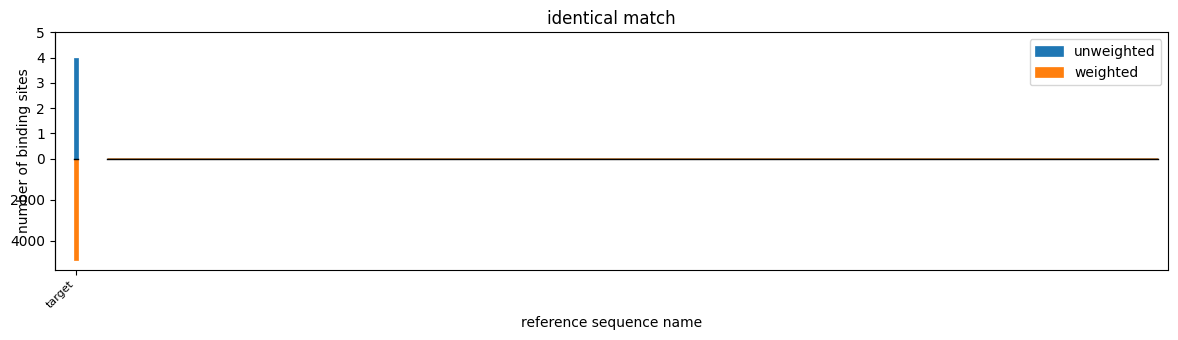

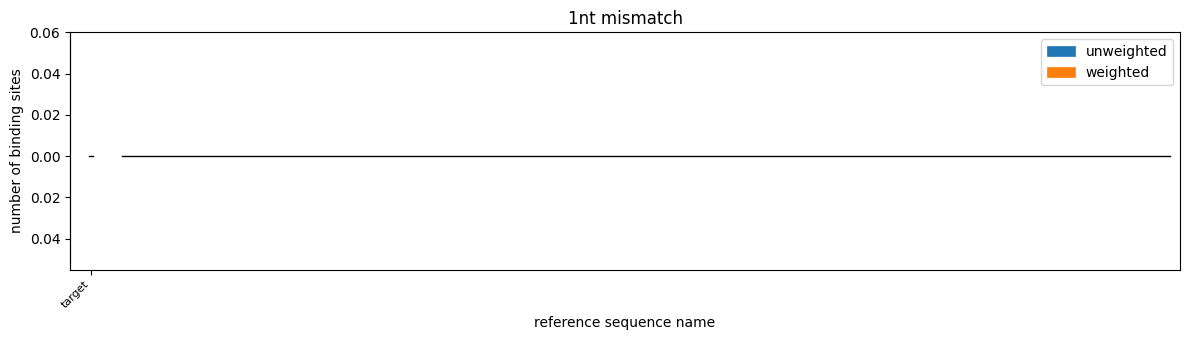

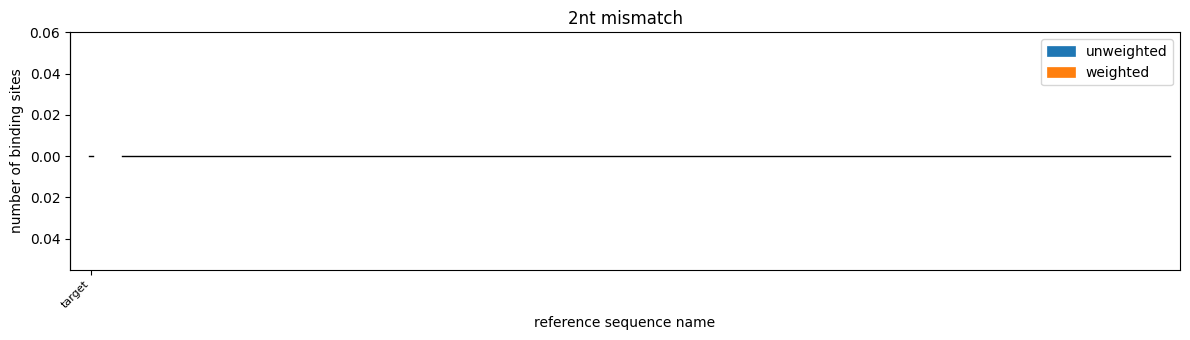

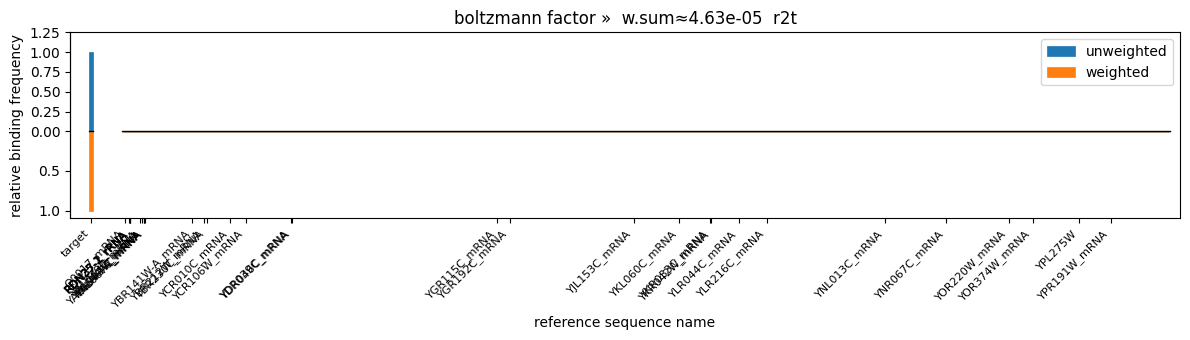



------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0032: AGCGGCATGGTTAGTAAAGGAGA
0203: GGTGGCCCATTACCATTTGCATG
0355: CGGTGGCGTGGTAACAGTGACTC
0442: ATCTGACGGCCCGGTTATGCAAA


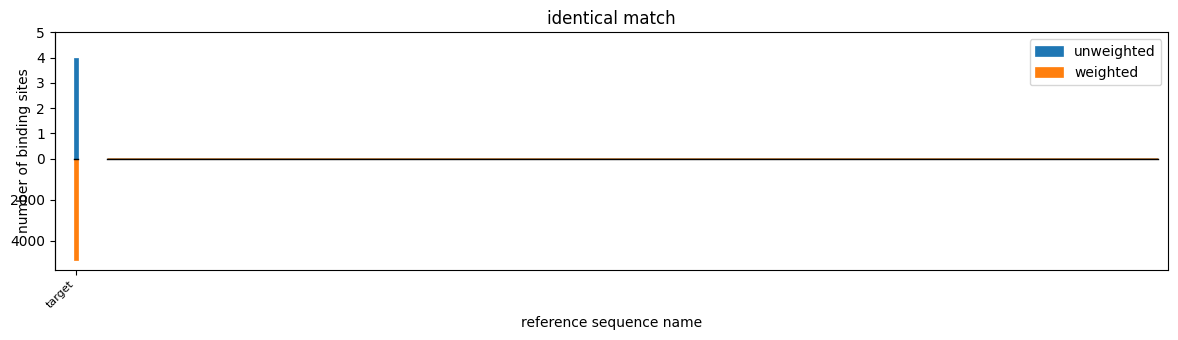

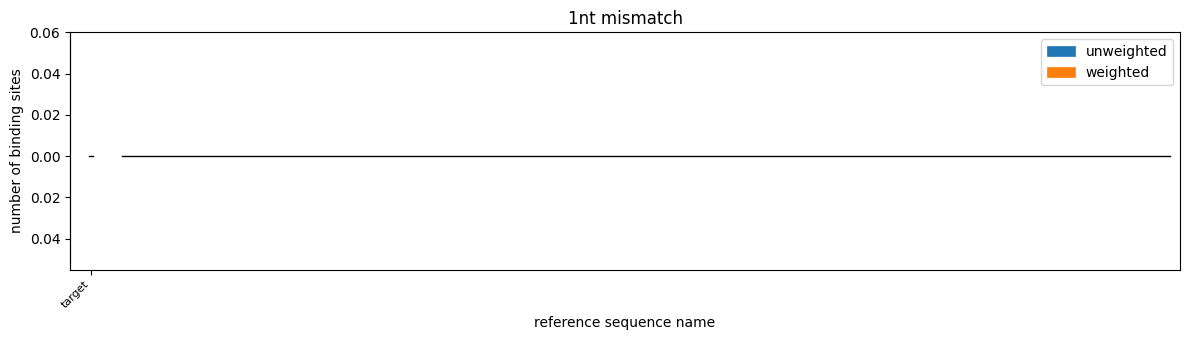

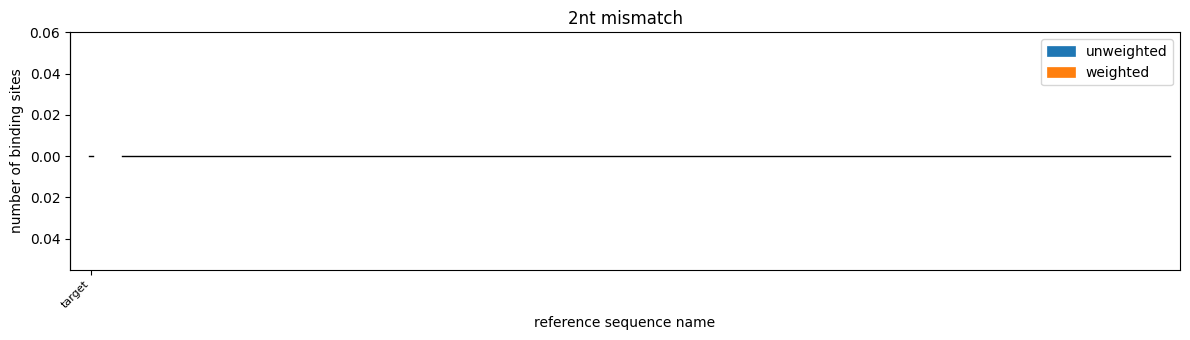

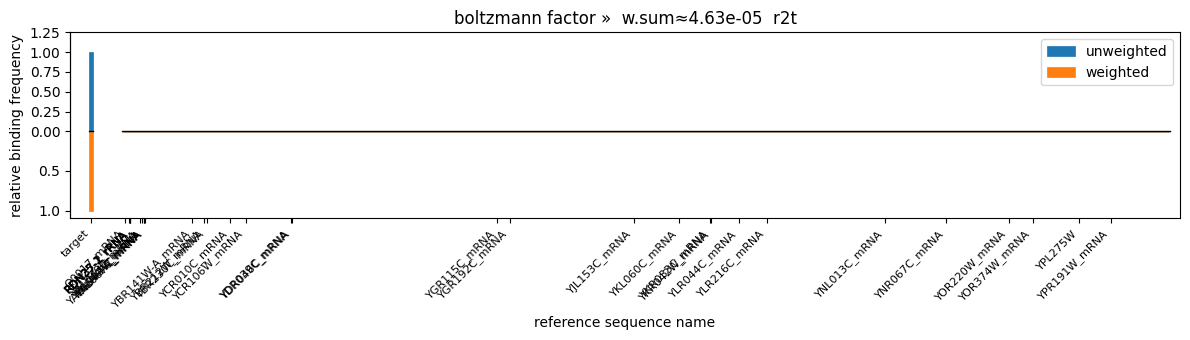



------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0203: GGTGGCCCATTACCATTTGCATG
0328: GTGGGAGCGTGTGATGAACTTCG
0442: ATCTGACGGCCCGGTTATGCAAA
0707: GGGAGACATAGTACTGGTGGCAT


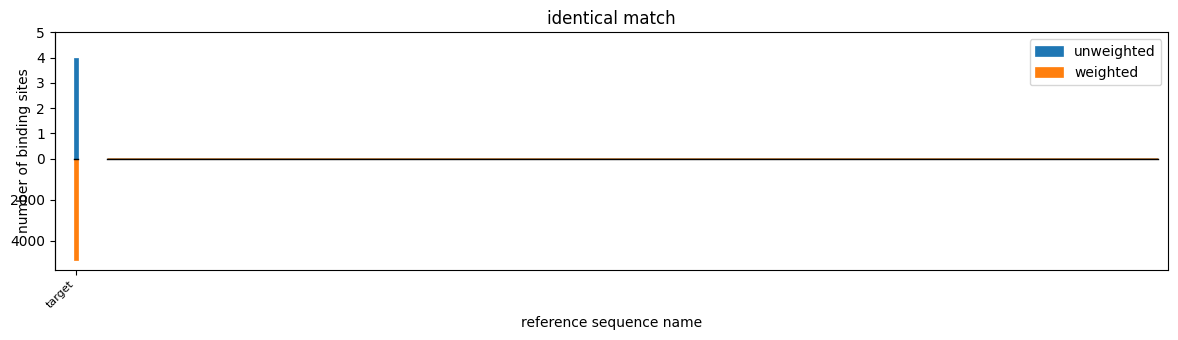

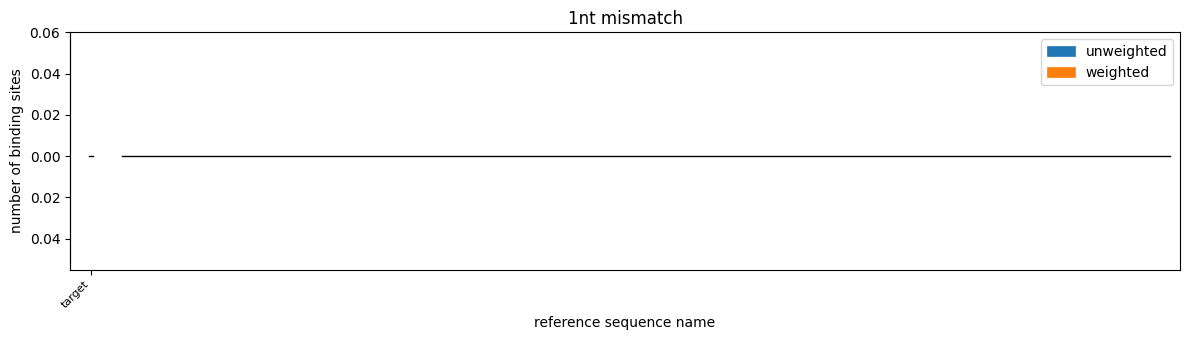

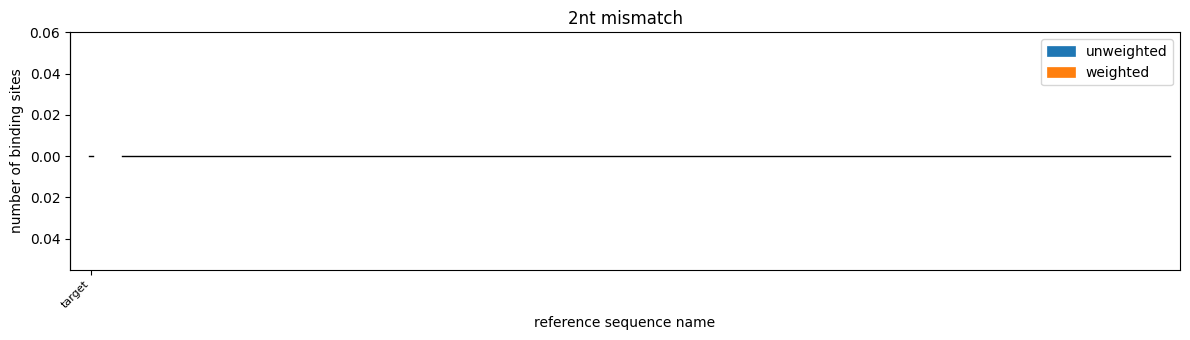

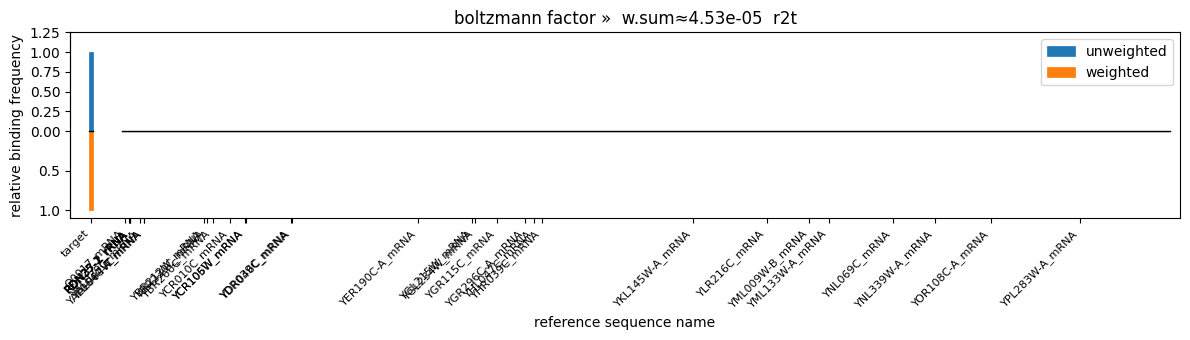



------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0203: GGTGGCCCATTACCATTTGCATG
0355: CGGTGGCGTGGTAACAGTGACTC
0442: ATCTGACGGCCCGGTTATGCAAA
0707: GGGAGACATAGTACTGGTGGCAT


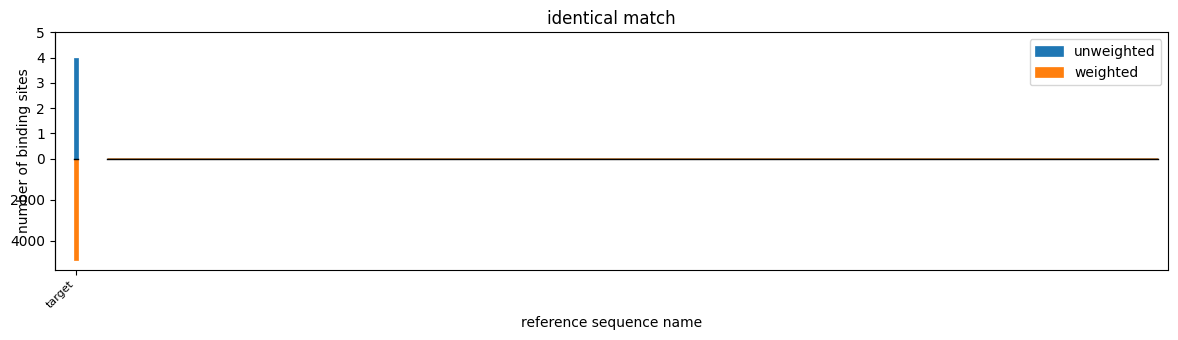

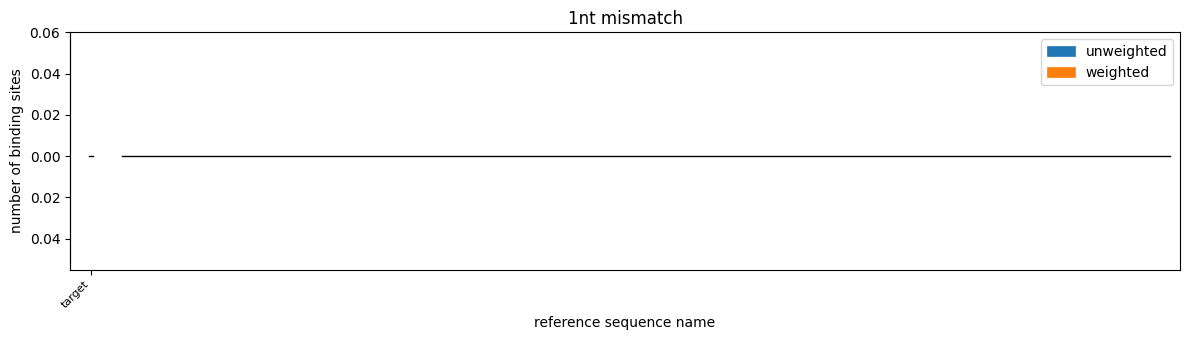

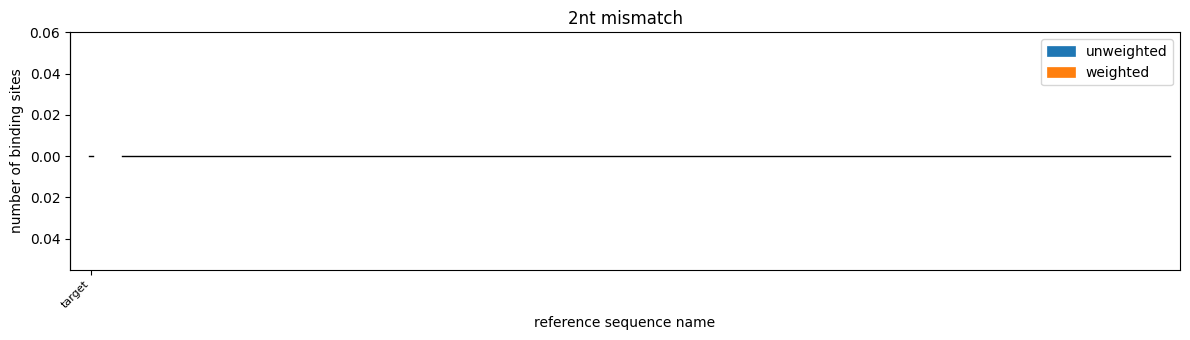

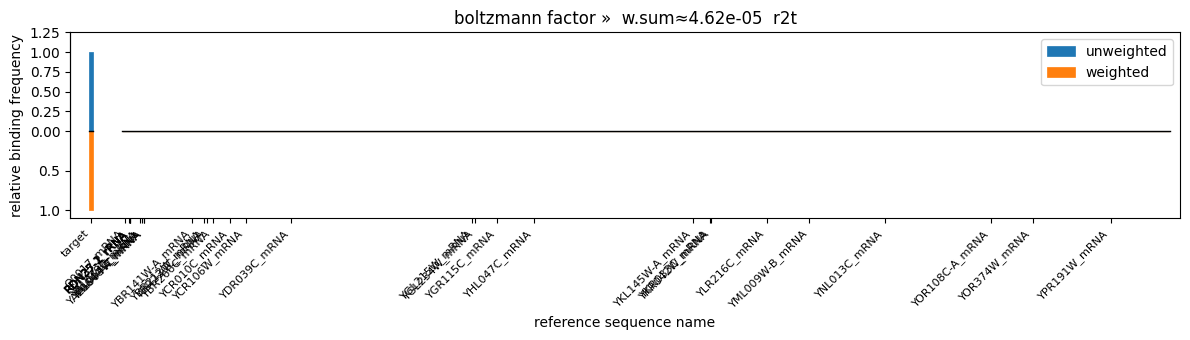



------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0203: GGTGGCCCATTACCATTTGCATG
0327: AGTGGGAGCGTGTGATGAACTTC
0442: ATCTGACGGCCCGGTTATGCAAA
0707: GGGAGACATAGTACTGGTGGCAT


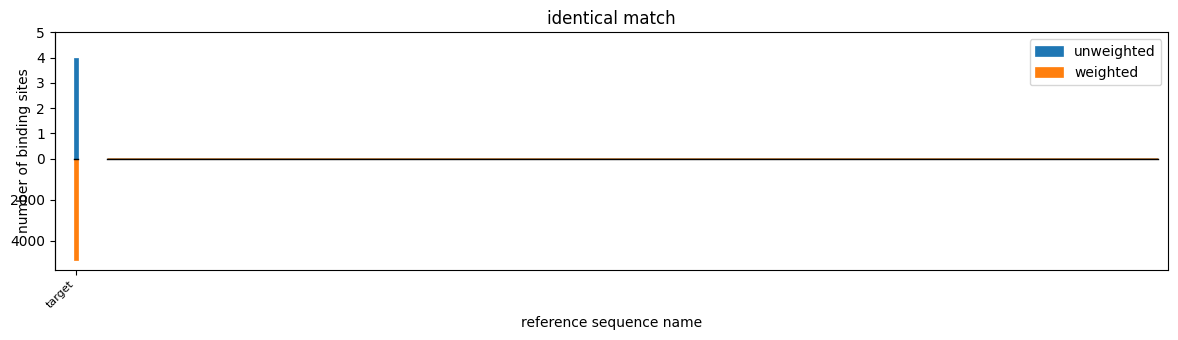

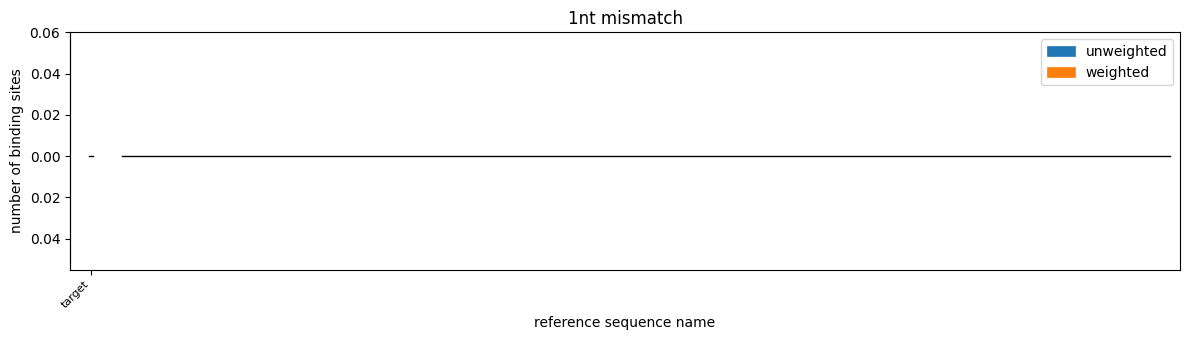

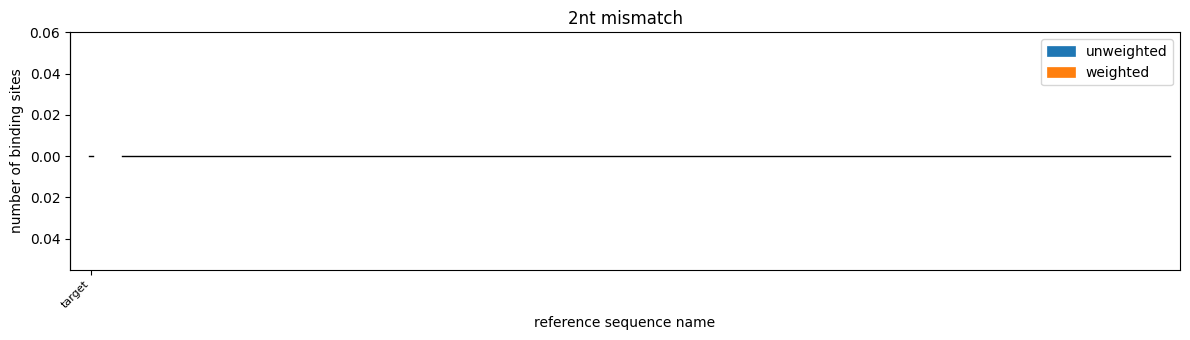

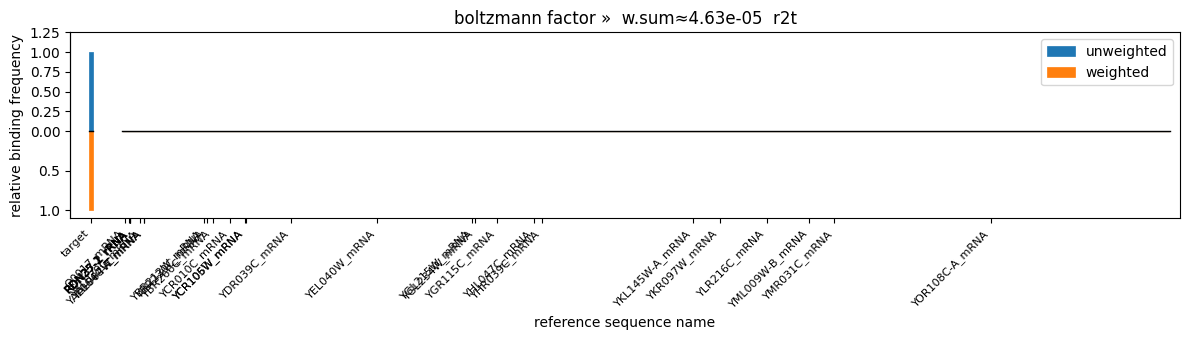

In [23]:
df = DF[DF.selected == 1]
for _, qc_indices in df.filter(like="POSITION").iterrows():
    positions = {}
    metrics = ["identical match", "1nt mismatch", "2nt mismatch", "boltzmann factor"]
    weight = 0
    print("\n")
    print("---"*100)
    for i, (query, scr) in enumerate([qnscr_dict[position] for position in qc_indices.values]):
        positions |= {f"POSITION {i}": query.POSITION}
        weight += query.WEIGHT
        print(f"{query.POSITION:04d}: {query.SEQUENCE}")
        if i == 0:
            references_scr = scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)  # results from the comparison with the reference dataset (sequences to avoid)
            target_scr     = scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0]  # results from the comparison with the target sequence
        else:
            references_scr[metrics] += scr.loc[~(scr.SEQ_NAME == target.SEQ_NAME)].reset_index(drop = True)[metrics]  # results from the comparison with the reference dataset (sequences to avoid)
            target_scr[metrics]     += scr.loc[  scr.SEQ_NAME == target.SEQ_NAME ].reset_index(drop = True).iloc[0][metrics]  # results from the comparison with the target sequence

    sc_summarize(pd.Series(positions|{"WEIGHT": weight}), references_scr,  target_scr, plot = True, VIR_max = 32) 

In [24]:
df = pd.read_csv("sequence_data/mcherry-rna-secstructure-CasRxguides.csv").rename(columns={'GuideSeq': 'SEQUENCE', 'GuideName': 'SEQ_NAME', 'MatchPos':'POSITION' })
df = df[df.POSITION.isin([32, 203, 355, 442, 707])].sort_values("POSITION")
df.SEQUENCE

93     TCTCCTTTACTAACCATGCCGCT
36     CATGCAAATGGTAATGGGCCACC
29     GAGTCACTGTTACCACGCCACCG
103    TTTGCATAACCGGGCCGTCAGAT
79     ATGCCACCAGTACTATGTCTCCC
Name: SEQUENCE, dtype: object